In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

In [41]:
class GeometricTransformer:
    def __init__(self, image_path="/content/pic.jpg"):
        """Initialize with image path - ONLY 4 main geometric transformations"""
        self.image_path = image_path
        self.img_pil = Image.open(image_path)
        self.img_cv = cv2.imread(image_path)

    def translate(self, tx=50, ty=30):
        """TRANSLATION: Shift image using padding/cropping (no affine)"""
        width, height = self.img_pil.size

        # PIL Translation - Create larger canvas with white background
        new_img = Image.new("RGB", (width + abs(tx)*2, height + abs(ty)*2), (255, 255, 255))
        new_img.paste(self.img_pil, (abs(tx), abs(ty)))
        translated_pil = new_img.crop((tx, ty, tx+width, ty+height))

        # OpenCV Translation - Add padding then crop
        rows, cols = self.img_cv.shape[:2]
        pad_top, pad_bottom = max(ty, 0), max(-ty, 0)
        pad_left, pad_right = max(tx, 0), max(-tx, 0)
        padded = cv2.copyMakeBorder(self.img_cv, pad_top, pad_bottom,
                                   pad_left, pad_right, cv2.BORDER_CONSTANT, value=[255,255,255])
        translated_cv = padded[pad_top:pad_top+rows, pad_left:pad_left+cols]

        return translated_pil, translated_cv

    def rotate(self, angle=45):
        """ROTATION: Using built-in rotate methods"""
        # PIL rotation with automatic canvas expansion
        rotated_pil = self.img_pil.rotate(angle, expand=True)

        # OpenCV rotation around center
        h, w = self.img_cv.shape[:2]
        center = (w//2, h//2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_cv = cv2.warpAffine(self.img_cv, rot_mat, (w, h))

        return rotated_pil, rotated_cv

    def scale(self, scale_x=1.5, scale_y=0.8):
        """SCALING: Using built-in resize methods"""
        # PIL resize with Lanczos interpolation (high quality)
        w, h = self.img_pil.size
        scaled_pil = self.img_pil.resize((int(w*scale_x), int(h*scale_y)), Image.LANCZOS)

        # OpenCV resize (note: OpenCV uses height,width order)
        h_cv, w_cv = self.img_cv.shape[:2]
        scaled_cv = cv2.resize(self.img_cv, (int(w_cv*scale_x), int(h_cv*scale_y)),
                              interpolation=cv2.INTER_LANCZOS4)

        return scaled_pil, scaled_cv

    def shear(self, shear_x=0.3, shear_y=0.2):
        """SHEAR: Pixel coordinate remapping (no matrix multiplication)"""
        # Convert PIL to numpy array for pixel manipulation
        img_array = np.array(self.img_pil)
        h, w = img_array.shape[:2]

        # Create coordinate grid for every pixel
        x_indices = np.arange(w)  # 0 to width-1
        y_indices = np.arange(h)  # 0 to height-1
        X, Y = np.meshgrid(x_indices, y_indices)  # 2D maps of all coordinates

        # Apply shear transformation to coordinates
        # Horizontal shear: x' = x + shear_x * y
        # Vertical shear: y' = y + shear_y * x
        shear_map_x = np.clip(X + shear_x * Y, 0, w-1).astype(np.int32)
        shear_map_y = np.clip(Y + shear_y * X, 0, h-1).astype(np.int32)

        # Remap pixels using new coordinates
        sheared = img_array[shear_map_y, shear_map_x]
        return Image.fromarray(sheared)

    def get_transformation(self, choice):
        """Get single transformation based on user input (1=Translation, 2=Rotation, 3=Scaling, 4=Shear)"""
        if choice == 1:
            tx = float(input("Enter translate x: "))
            ty = float(input("Enter translate y: "))
            translated_pil, _ = self.translate(tx,ty)
            return 'Translation', translated_pil
        elif choice == 2:
            angle = float(input("Enter rotation angle: "))
            rotated_pil, _ = self.rotate(angle)
            return 'Rotation', rotated_pil
        elif choice == 3:
            sx = float(input("Enter scale x: "))
            sy = float(input("Enter scale y: "))
            scaled_pil, _ = self.scale(sx,sy)
            return 'Scaling', scaled_pil
        elif choice == 4:
            shx = float(input("Enter shear x: "))
            shy = float(input("Enter shear y: "))
            return 'Shear', self.shear(shx,shy)
        else:
            return 'Invalid choice', self.img_pil

    def interactive_menu(self):
        """Interactive menu with user input"""
        while True:
            print("\n" + "="*50)
            print("🎯 GEOMETRIC TRANSFORMATIONS MENU")
            print("="*50)
            print("1. Translation (Shift)")
            print("2. Rotation")
            print("3. Scaling")
            print("4. Shearing")
            print("0. Exit")
            print("-"*50)

            try:
                choice = int(input("Enter your choice (0-4): "))

                if choice == 0:
                    print("👋 Goodbye!")
                    break

                name, result_img = self.get_transformation(choice)

                if name != 'Invalid choice':
                    # Display result
                    plt.figure(figsize=(8, 6))
                    plt.imshow(result_img)
                    plt.title(f'{name} Transformation', fontsize=16, fontweight='bold')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("❌ Invalid choice! Please select 1-4.")

            except ValueError:
                print("❌ Please enter a valid number!")
            except KeyboardInterrupt:
                print("\n👋 Exiting...")
                break

In [42]:
class FlexibleAffine:

    def __init__(self, image_path):
        self.image_path = image_path
        self.img = None
        self.rows = None
        self.cols = None
        self.matrix = np.eye(3)

    # 1️⃣ Read Image
    def read_image(self):
        self.img = cv2.imread(self.image_path, 0)
        self.rows, self.cols = self.img.shape

    # 2️⃣ Rotation
    def add_rotation(self, angle):
        center = (self.cols // 2, self.rows // 2)
        rot = cv2.getRotationMatrix2D(center, angle, 1)
        rot = np.vstack([rot, [0,0,1]])
        self.matrix = rot @ self.matrix

    # 3️⃣ Scaling
    def add_scaling(self, sx, sy):
        scale = np.array([[sx,0,0],
                          [0,sy,0],
                          [0,0,1]])
        self.matrix = scale @ self.matrix

    # 4️⃣ Shearing
    def add_shearing(self, shx, shy):
        shear = np.array([[1,shx,0],
                          [shy,1,0],
                          [0,0,1]])
        self.matrix = shear @ self.matrix

    # 5️⃣ Translation
    def add_translation(self, tx, ty):
        trans = np.array([[1,0,tx],
                          [0,1,ty],
                          [0,0,1]])
        self.matrix = trans @ self.matrix

    # 6️⃣ Apply Affine
    def apply(self):
        final_matrix = self.matrix[:2, :]
        result = cv2.warpAffine(self.img, final_matrix, (self.cols, self.rows))
        return result

    # 7️⃣ Display
    def display(self, result):
        plt.figure(figsize=(8, 6))
        plt.imshow(result)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # 8️⃣ User Menu Function (NEW)
    def user_menu(self):
      while True:
        print("Choose transformations:")
        print("1 - Rotation")
        print("2 - Scaling")
        print("3 - Shearing")
        print("4 - Translation")
        print("5 - Apply All")
        print("6 - Exit")

        choices = input("Enter numbers separated by comma (example: 1,3): ")

        if "1" in choices:
            angle = float(input("Enter rotation angle: "))
            self.add_rotation(angle)

        if "2" in choices:
            sx = float(input("Enter scale x: "))
            sy = float(input("Enter scale y: "))
            self.add_scaling(sx, sy)

        if "3" in choices:
            shx = float(input("Enter shear x: "))
            shy = float(input("Enter shear y: "))
            self.add_shearing(shx, shy)

        if "4" in choices:
            tx = float(input("Enter translate x: "))
            ty = float(input("Enter translate y: "))
            self.add_translation(tx, ty)

        if "5" in choices:
            self.add_rotation(30)
            self.add_scaling(1.2, 1.2)
            self.add_shearing(0.2, 0)
            self.add_translation(50, 30)

        if "6" in choices:
            break

        result = self.apply()
        self.display(result)

In [43]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    # Since Colab drops it in the current working directory (/content)
    full_path = os.path.abspath(filename)

Saving totoro-5k-3840x2160-23493.png to totoro-5k-3840x2160-23493.png


Choose Affine or Geometric:
 1. Affine
 2. Geometric
2

🎯 GEOMETRIC TRANSFORMATIONS MENU
1. Translation (Shift)
2. Rotation
3. Scaling
4. Shearing
0. Exit
--------------------------------------------------
Enter your choice (0-4): 2
Enter rotation angle: 45


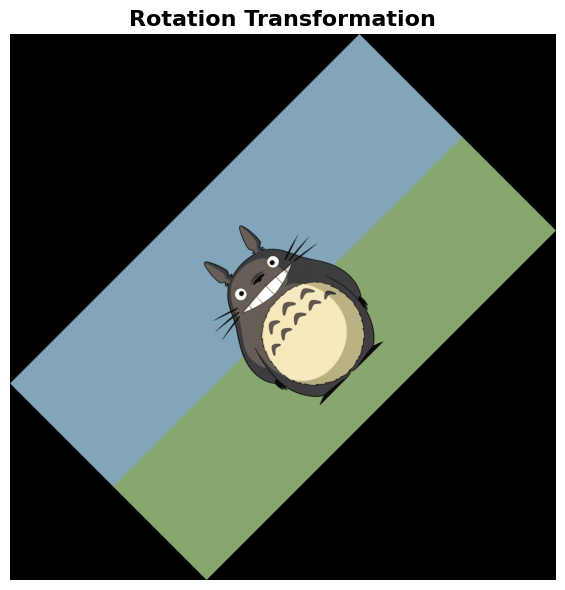


🎯 GEOMETRIC TRANSFORMATIONS MENU
1. Translation (Shift)
2. Rotation
3. Scaling
4. Shearing
0. Exit
--------------------------------------------------
Enter your choice (0-4): 0
👋 Goodbye!


In [45]:
choice = int(input("Choose Affine or Geometric:\n 1. Affine\n 2. Geometric\n"))
if choice == 1:
  obj = FlexibleAffine(full_path)
  obj.read_image()
  obj.user_menu()
elif choice == 2:
  obj = GeometricTransformer(full_path)
  obj.interactive_menu()
